In [56]:
from xbbg import blp

import pandas as pd
import numpy as np
from datetime import datetime, timedelta

from scipy.interpolate import interp1d

import matplotlib.pyplot as plt

: 

In [107]:
# Getting 
def riskFreeCurve(ccy):


    if ccy == 'USD':
        ois_tickers = [
        'USSO1Z BGN Curncy', # 1W
        'USSO2Z BGN Curncy', # 2W
        'USSO3Z BGN Curncy', # 3W
        'USSOA BGN Curncy', # 1M
        'USSOB BGN Curncy', # 2M
        'USSOC BGN Curncy', # 3M
        'USSOF BGN Curncy', # 6M
        'USSO1 BGN Curncy', # 1Y
        'USSO1F BGN Curncy', # 18M
        'USSO2 BGN Curncy', # 2Y
        ]



    end_date = datetime.now().strftime("%Y-%m-%d")
    start_date = (datetime.now() - timedelta(days=3)).strftime("%Y-%m-%d")


    names = ['1W', '2W', '3W', '1M', '2M', '3M', '6M', '1Y', '18M', '2Y']

    # Gather data
    ois_data = blp.bdh(
        tickers=ois_tickers,
        flds='PX_LAST',
        start_date=start_date,
        end_date=end_date
    )

    # Clean dataframe 
    ois_rates = ois_data.iloc[-1].reset_index()
    ois_rates['level_0'] = names
    ois_rates = ois_rates.drop(columns=['level_1'])
    ois_rates.columns = ['Tenor', 'Rate']
    ois_rates['Rate'] /= 100 




    tenor_map = {'W': 7/365, 'M': 30/365, 'Y': 1}
    ois_rates['Time'] = ois_rates['Tenor'].str.extract(r'(\d+)([WMY])') \
        .apply(lambda x: int(x[0]) * tenor_map[x[1]], axis=1)

    discount_factors = [4.5]


    for i, rate in enumerate(ois_rates['Rate']):
        t = ois_rates.loc[i, 'Time']
        discount_factors.append(1 / (1 + rate * t))

    ois_rates['DiscountFactor'] = discount_factors[1:]




    def interpolate_discount_curve(ois_curve):

        return interp1d(
            ois_curve['Time'], ois_curve['DiscountFactor'], 
            kind='cubic', fill_value='extrapolate'
    )



    interp_func = interpolate_discount_curve(ois_rates)
    
    return interp_func



In [108]:
ccy = 'USD'

USD = riskFreeCurve(ccy)


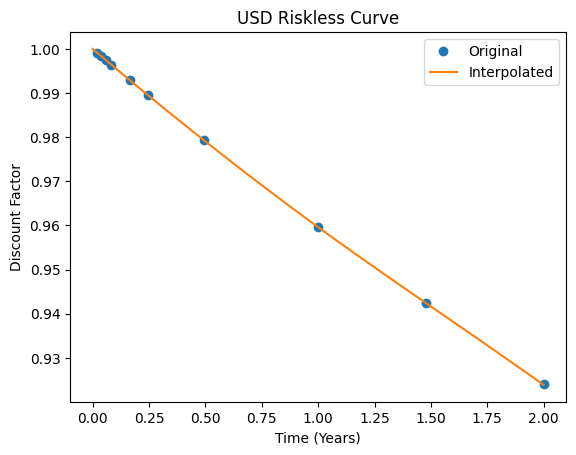

In [109]:
times = np.linspace(0, max(ois_rates['Time']), 100)
discount_factors = USD(times)

plt.plot(ois_rates['Time'], ois_rates['DiscountFactor'], 'o', label='Original')
plt.plot(times, discount_factors, label='Interpolated')
plt.xlabel('Time (Years)')
plt.ylabel('Discount Factor')
plt.title('USD Riskless Curve')
plt.legend()
plt.show()

In [145]:
def riskFreeRateCurve(ccy, days_till):
    # US OIS Rates
    if ccy == 'USD':
        ois_tickers = [
            'USSO1Z BGN Curncy', 'USSO2Z BGN Curncy', 'USSO3Z BGN Curncy',
            'USSOA BGN Curncy', 'USSOB BGN Curncy', 'USSOC BGN Curncy', 
            'USSOF BGN Curncy', 'USSO1 BGN Curncy', 'USSO1F BGN Curncy', 
            'USSO2 BGN Curncy']

    # EUR OIS Rates
    if ccy == 'EUR':
        ois_tickers = [
            'EESWE1Z BGN Curncy', 'EESWE2Z BGN Curncy', 'EESWE3Z BGN Curncy', 
            'EESWEA BGN Curncy', 'EESWEB BGN Curncy', 'EESWEC BGN Curncy', 
            'EESWEF BGN Curncy', 'EESWE1 BGN Curncy', 'EESWE1F BGN Curncy', 
            'EESWE2 BGN Curncy']

    # GBP OIS Rates
    if ccy == 'GBP':
        ois_tickers = [
            'BPSWS1Z BGN Curncy', 'BPSWS2Z BGN Curncy', 'BPSWS3Z BGN Curncy', 
            'BPSWSA BGN Curncy', 'BPSWSB BGN Curncy', 'BPSWSC BGN Curncy', 
            'BPSWSF BGN Curncy', 'BPSWS1 BGN Curncy', 'BPSWS1F BGN Curncy', 
            'BPSWS2 BGN Curncy']

    # JPY OIS Rates
    if ccy == 'JPY':
        ois_tickers = [
            'JYSO1Z BGN Curncy', 'JYSO2Z BGN Curncy', 'JYSO3Z BGN Curncy', # 3W
            'JYSOA BGN Curncy', 'JYSOB BGN Curncy', 'JYSOC BGN Curncy', # 3M
            'JYSOF BGN Curncy', 'JYSO1 BGN Curncy', 'JYSO1F BGN Curncy', # 18M
            'JYSO2 BGN Curncy']


    # CAD OIS Rates
    if ccy == 'CAD':
        ois_tickers = [
            'CDSO1Z BGN Curncy', 'CDSO2Z BGN Curncy', 'CDSO3Z BGN Curncy', # 3W
            'CDSOA BGN Curncy', 'CDSOB BGN Curncy', 'CDSOC BGN Curncy', # 3M
            'CDSOF BGN Curncy', 'CDSO1 BGN Curncy', 'CDSO1F BGN Curncy', # 18M
            'CDSO2 BGN Curncy']



    # CHF OIS Rates
    if ccy == 'CHF':
        ois_tickers = [
            'SFSNT1Z BGN Curncy', 'SFSNT2Z BGN Curncy', 'SFSNT3Z BGN Curncy', # 3W
            'SFSNTA BGN Curncy', 'SFSNTB BGN Curncy', 'SFSNTC BGN Curncy', # 3M
            'SFSNTF BGN Curncy', 'SFSNT1 BGN Curncy', 'SFSNT1F BGN Curncy', # 18M
            'SFSNT2 BGN Curncy']

    # AUD OIS Rates
    if ccy == 'AUD':
        ois_tickers = [
            'ADSO1Z BGN Curncy', 'ADSO2Z BGN Curncy', 'ADSO3Z BGN Curncy', # 3W
            'ADSOA BGN Curncy', 'ADSOB BGN Curncy', 'ADSOC BGN Curncy', # 3M
            'ADSOF BGN Curncy', 'ADSO1 BGN Curncy', 'ADSO1F BGN Curncy', # 18M
            'ADSO2 BGN Curncy']

    # NZD OIS Rates
    if ccy == 'NZD':
        ois_tickers = [
            'NDSO1Z BGN Curncy', 'NDSO2Z BGN Curncy', 'NDSO3Z BGN Curncy', # 3W
            'NDSOA BGN Curncy', 'NDSOB BGN Curncy', 'NDSOC BGN Curncy', # 3M
            'NDSOF BGN Curncy', 'NDSO1 BGN Curncy', 'NDSO1F BGN Curncy', # 18M
            'NDSO2 BGN Curncy']


    end_date = datetime.now().strftime("%Y-%m-%d")
    start_date = (datetime.now() - timedelta(days=3)).strftime("%Y-%m-%d")

    names = ['1W', '2W', '3W', '1M', '2M', '3M', '6M', '1Y', '18M', '2Y']

    # Gather data
    ois_data = blp.bdh(
        tickers=ois_tickers,
        flds='PX_LAST',
        start_date=start_date,
        end_date=end_date
    )

    # Clean dataframe
    ois_rates = ois_data.iloc[-1].reset_index()
    ois_rates['level_0'] = names
    ois_rates = ois_rates.drop(columns=['level_1'])
    ois_rates.columns = ['Tenor', 'Rate']
    ois_rates['Rate'] /= 100  # Convert percentages to decimals

    # Map tenors to times (in years)
    tenor_map = {'W': 7 / 365, 'M': 30 / 365, 'Y': 1}
    ois_rates['Time'] = ois_rates['Tenor'].str.extract(r'(\d+)([WMY])') \
        .apply(lambda x: int(x[0]) * tenor_map[x[1]], axis=1)

    # Interpolate the rate curve directly
    def interpolate_rate_curve(ois_curve):
        return interp1d(
            ois_curve['Time'], ois_curve['Rate'],
            kind='cubic', fill_value='extrapolate'
        )

    # Create the interpolation function
    interp_func = interpolate_rate_curve(ois_rates)
    
    # Convert days to years
    time_in_years = days_till / 365
    
    # Get the interpolated rate
    interpolated_rate = interp_func(time_in_years)
    
    return interpolated_rate

In [146]:
ccy = 'NZD'
days_till = 31

riskFreeRateCurve(ccy, days_till)

array(0.04192712)